# IE493 Project — Phase 2: Preemptive-Resume Priority ER Simulation

**Group 12** — Erdoğan Kocabaş (2021402183) & Berru Selcan Cocen (2021402003)

---

## Overview

Phase 2 extends the Phase 1 FCFS model by introducing a **triage-based priority system** with three patient classes:

| Priority | Class | Behaviour |
|:--------:|:-----:|:----------|
| 1 (highest) | **Red** (Emergency) | Can preempt Green or Yellow patients from treatment |
| 2 | **Yellow** (Urgent) | Does not preempt, but queues ahead of Green |
| 3 (lowest) | **Green** (Non-urgent) | Lowest priority; can be interrupted by Red |

The simulation follows **Preemptive-Resume** rules: interrupted patients retain their remaining work and resume from where they left off when a doctor becomes available.

**Key system parameters from Phase 1:** 5 doctors, $\lambda = 0.2452$ pat/min, $\mu = 0.0647$ pat/min/doctor, $\rho = 0.7582$, $C_v = 0.39$

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import heapq
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Constants ──
C = 5              # Number of doctors
RED, YELLOW, GREEN = 1, 2, 3
PRIORITY_MAP   = {'Red': RED, 'Yellow': YELLOW, 'Green': GREEN}
PRIORITY_NAMES = {RED: 'Red', YELLOW: 'Yellow', GREEN: 'Green'}
PRIORITY_COLORS = {'Red': '#e74c3c', 'Yellow': '#f39c12', 'Green': '#27ae60'}

# 1. Data Loading & Preprocessing

Load the Group 12 dataset with priority labels. Parse arrival clock times into minutes from ER opening (08:00), handling day rollovers for the multi-day trace.

In [62]:
# Load dataset (with Priority column)
df = pd.read_csv('Group_12/ER_Phase2_Group_12.csv')
print(f"Loaded {len(df)} patients")
print(f"Columns: {list(df.columns)}")
print()

# Parse Arrival_Clock -> minutes from 08:00
# Handle day rollover: when HH:MM:SS goes backward, a new day started
ER_OPEN_HOUR = 8  # 08:00

day_offset = 0
prev_total_sec = -1
arrival_minutes = []

for t_str in df['Arrival_Clock']:
    parts = t_str.strip().split(':')
    h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
    total_sec = h * 3600 + m * 60 + s

    # Detect midnight rollover (with 1-hour tolerance)
    if prev_total_sec >= 0 and total_sec < prev_total_sec - 3600:
        day_offset += 1
    prev_total_sec = total_sec

    minutes_from_open = (day_offset * 24 * 60) + (h * 60 + m + s / 60.0) - (ER_OPEN_HOUR * 60)
    arrival_minutes.append(minutes_from_open)

df['arrival_min'] = arrival_minutes

# Map priority strings to numeric levels
df['priority_num'] = df['Priority'].map(PRIORITY_MAP)

# Display summary
print("Priority distribution:")
print(df['Priority'].value_counts().to_string())
print()
print(f"Arrival time range: {df['arrival_min'].min():.2f} to {df['arrival_min'].max():.2f} min from 08:00")
print(f"Total observation span: {df['arrival_min'].max() / 60:.1f} hours")
print()
print("First 10 patients:")
df[['Patient_ID', 'Arrival_Clock', 'Priority', 'Service_Required_Min', 'arrival_min']].head(10)

Loaded 1000 patients
Columns: ['Patient_ID', 'Arrival_Clock', 'Priority', 'Service_Required_Min']

Priority distribution:
Priority
Green     637
Yellow    292
Red        71

Arrival time range: 0.68 to 4078.53 min from 08:00
Total observation span: 68.0 hours

First 10 patients:


,Patient_ID,Arrival_Clock,Priority,Service_Required_Min,arrival_min
0,1000,08:00:41,Green,10.45,0.683333
1,1001,08:11:00,Green,19.92,11.000000
2,1002,08:11:01,Green,8.08,11.016667
3,1003,08:13:45,Green,11.69,13.750000
4,1004,08:14:21,Green,12.90,14.350000
5,1005,08:21:19,Yellow,11.21,21.316667
6,1006,08:26:18,Green,9.26,26.300000
7,1007,08:38:39,Green,9.07,38.650000
8,1008,08:40:48,Green,6.20,40.800000
9,1009,08:54:19,Green,7.62,54.316667


# 2. Simulation Engine: Event-Queue Timeline

> **Note from project spec:** *"This phase cannot be solved with a single formula. You must build a timeline. Focus on the 'State Change' that happens every time a Red patient arrives. Accuracy in tracking 'Remaining Work' is the most common area for errors."*

The simulation uses an **event-driven architecture** with two event types processed in strict chronological order via a min-heap:

| Event | Trigger | Action |
|-------|---------|--------|
| `COMPLETION` | Doctor finishes patient | Free doctor, pull next from waiting queue (Resume Rule) |
| `ARRIVAL` | Patient arrives | Assign to doctor, queue, or trigger preemption |

### Preemption Rules (Red patient arrives, all 5 doctors busy):
1. Scan for doctors treating **Green** patients first; if none, check **Yellow**
2. Among eligible, preempt the one **closest to finishing** (smallest remaining work)
3. Calculate `remaining_work = busy_until - current_time` at the **exact moment** of preemption
4. Interrupted patient returns to the **front** of their priority class queue
5. Red patient starts immediately on the freed doctor

> **Critical:** `remaining_work` is always recalculated from the current state, never from the original service time. A patient preempted multiple times has progressively smaller remaining work each time.

In [63]:
def min_to_clock(minutes):
    """Convert minutes from 08:00:00 to HH:MM:SS clock string."""
    total_sec = round(minutes * 60)
    base_sec  = 8 * 3600  # 08:00:00
    total_sec += base_sec

    day = total_sec // 86400
    rem = total_sec % 86400
    h   = rem // 3600
    mi  = (rem % 3600) // 60
    s   = rem % 60

    clock = f"{h:02d}:{mi:02d}:{s:02d}"
    if day > 0:
        return f"Day{day + 1} {clock}"
    return clock

# Quick test
print("0.683 min from 08:00 ->", min_to_clock(0.683))  # Should be ~08:00:41
print("1500 min from 08:00 ->", min_to_clock(1500))     # Should be Day2 09:00:00

0.683 min from 08:00 -> 08:00:41
1500 min from 08:00 -> Day2 09:00:00


In [64]:
def simulate_preemptive_resume(df, verbose=False):
    """
    Run the Preemptive-Resume priority simulation on the ER dataset.

    Architecture: Event-queue timeline with two event types (ARRIVAL, COMPLETION)
    processed via a min-heap in strict chronological order.

    Preemption: Only Red patients can preempt. They preempt the doctor treating
    the lowest-priority patient closest to finishing (Green first, then Yellow).

    Parameters
    ----------
    df : DataFrame
        Must have columns: Patient_ID, arrival_min, priority_num, Service_Required_Min
    verbose : bool
        If True, print detailed event log for debugging

    Returns
    -------
    results : DataFrame
        Per-patient results with timing and interruption data
    total_preemptions : int
        Total number of preemption events
    preemption_log : list of dict
        Detailed log of each preemption event
    """

    # ── Event type constants ──
    # COMPLETION = 0 so it is processed BEFORE ARRIVAL = 1 at the same timestamp
    EVT_COMPLETION = 0
    EVT_ARRIVAL    = 1

    n = len(df)

    # ── Extract arrays for speed ──
    arrival   = df['arrival_min'].values.astype(float)
    priority  = df['priority_num'].values.astype(int)
    service   = df['Service_Required_Min'].values.astype(float)
    pat_ids   = df['Patient_ID'].values

    # ── Patient state ──
    remaining_work       = service.copy()          # Decremented on each preemption
    interruptions        = np.zeros(n, dtype=int)
    first_start          = np.full(n, np.nan)      # First time treatment begins
    final_end            = np.full(n, np.nan)      # Time treatment fully completes
    docs_busy_on_arrival = np.zeros(n, dtype=int)   # How many doctors busy when patient arrives

    # ── Doctor state (5 doctors) ──
    doc_busy       = [False] * C
    doc_patient    = [None]  * C             # Index of patient currently being treated
    doc_busy_until = [0.0]   * C             # Scheduled completion time
    doc_version    = [0]     * C             # For lazy event cancellation

    # ── Waiting queues (one deque per priority class) ──
    # Preempted patients -> appendleft (FRONT), new patients -> append (BACK)
    wait_q = {RED: deque(), YELLOW: deque(), GREEN: deque()}

    # ── Event queue (min-heap) ──
    # Format: (time, event_type, tiebreak, patient_idx, doctor_idx, version)
    event_q = []
    for i in range(n):
        heapq.heappush(event_q, (arrival[i], EVT_ARRIVAL, i, i, -1, -1))

    event_counter     = n    # Monotonic counter for tiebreaking
    total_preemptions = 0
    preemption_log    = []

    # ─────────────────────────────────────────────────────────────
    # Helper: assign a patient to a doctor and schedule COMPLETION
    # ─────────────────────────────────────────────────────────────
    def assign_to_doctor(pat_idx, doc_idx, t):
        nonlocal event_counter

        svc_duration = remaining_work[pat_idx]

        doc_busy[doc_idx]       = True
        doc_patient[doc_idx]    = pat_idx
        doc_busy_until[doc_idx] = t + svc_duration
        doc_version[doc_idx]   += 1   # Invalidates any old COMPLETION for this doctor

        # Record first start time (only on initial assignment, not resume)
        if np.isnan(first_start[pat_idx]):
            first_start[pat_idx] = t

        # Schedule completion event
        heapq.heappush(event_q, (
            t + svc_duration,
            EVT_COMPLETION,
            event_counter,
            pat_idx,
            doc_idx,
            doc_version[doc_idx]
        ))
        event_counter += 1

        if verbose:
            status = "STARTS"
            if interruptions[pat_idx] > 0:
                status = f"RESUMES (remaining={svc_duration:.2f} min)"
            print(f"    -> Patient {pat_ids[pat_idx]} ({PRIORITY_NAMES[priority[pat_idx]]}) "
                  f"{status} on Doctor {doc_idx}, ends at {min_to_clock(t + svc_duration)}")

    # ─────────────────────────────────────────────────────────────
    # Helper: pull highest-priority patient from waiting queue
    # ─────────────────────────────────────────────────────────────
    def pull_from_queue():
        for prio in [RED, YELLOW, GREEN]:
            if wait_q[prio]:
                return wait_q[prio].popleft()
        return None

    # ─────────────────────────────────────────────────────────────
    # Helper: find any idle doctor
    # ─────────────────────────────────────────────────────────────
    def find_idle_doctor():
        for j in range(C):
            if not doc_busy[j]:
                return j
        return None

    # ═══════════════════════════════════════════════════════════
    # MAIN EVENT LOOP
    # ═══════════════════════════════════════════════════════════
    while event_q:
        t, etype, _, pat_idx, doc_idx, ver = heapq.heappop(event_q)

        # ═════ CASE A: COMPLETION EVENT ═════
        if etype == EVT_COMPLETION:
            # Lazy deletion: skip stale events
            if doc_version[doc_idx] != ver:
                continue

            # Mark patient as DONE
            final_end[pat_idx] = t

            if verbose:
                print(f"  t={min_to_clock(t)}: Patient {pat_ids[pat_idx]} "
                      f"({PRIORITY_NAMES[priority[pat_idx]]}) COMPLETED on Doctor {doc_idx}")

            # Free the doctor
            doc_busy[doc_idx]    = False
            doc_patient[doc_idx] = None

            # Resume Rule: pull next patient from waiting queue
            next_pat = pull_from_queue()
            if next_pat is not None:
                assign_to_doctor(next_pat, doc_idx, t)

        # ═════ CASE B: ARRIVAL EVENT ═════
        elif etype == EVT_ARRIVAL:
            pri = priority[pat_idx]

            # Record how many doctors are busy at this arrival
            docs_busy_on_arrival[pat_idx] = sum(doc_busy)

            if verbose:
                print()
                print(f"  t={min_to_clock(t)}: ARRIVAL Patient {pat_ids[pat_idx]} "
                      f"({PRIORITY_NAMES[pri]}), service={service[pat_idx]:.2f} min"
                      f" | Doctors busy: {docs_busy_on_arrival[pat_idx]}/5")

            # B1: Try to find an idle doctor
            idle_doc = find_idle_doctor()
            if idle_doc is not None:
                assign_to_doctor(pat_idx, idle_doc, t)
                continue

            # B2: All doctors busy — Yellow/Green just queue
            if pri != RED:
                wait_q[pri].append(pat_idx)
                if verbose:
                    print(f"    -> All doctors busy, joins {PRIORITY_NAMES[pri]} queue")
                continue

            # ═════════════════════════════════════════════════
            # B3: RED patient, all busy -> ATTEMPT PREEMPTION
            # ═════════════════════════════════════════════════

            # Step 1: Find preempt-able candidates (Green first, then Yellow)
            candidates = [
                j for j in range(C)
                if doc_busy[j] and priority[doc_patient[j]] == GREEN
            ]

            if not candidates:
                candidates = [
                    j for j in range(C)
                    if doc_busy[j] and priority[doc_patient[j]] == YELLOW
                ]

            if not candidates:
                # All 5 doctors treating Red — Red must wait
                wait_q[RED].append(pat_idx)
                if verbose:
                    print(f"    -> All doctors treating RED, joins Red queue")
                continue

            # Step 2: Pick the doctor CLOSEST TO FINISHING (smallest busy_until)
            victim_doc = min(candidates, key=lambda j: doc_busy_until[j])
            victim_pat = doc_patient[victim_doc]

            # ★★★ Step 3: CALCULATE REMAINING WORK ★★★
            # This is the critical calculation:
            #   remaining = scheduled_end - current_time
            # NOT the original service time!
            remaining = doc_busy_until[victim_doc] - t
            remaining_work[victim_pat] = remaining
            interruptions[victim_pat] += 1
            total_preemptions += 1

            # Log the preemption event
            preemption_log.append({
                'time': t,
                'time_clock': min_to_clock(t),
                'red_patient': int(pat_ids[pat_idx]),
                'victim_patient': int(pat_ids[victim_pat]),
                'victim_priority': PRIORITY_NAMES[priority[victim_pat]],
                'remaining_work': round(remaining, 4),
                'doctor': victim_doc,
                'victim_interruption_count': int(interruptions[victim_pat])
            })

            if verbose:
                print(f"    ** PREEMPTION: Doctor {victim_doc} was treating "
                      f"Patient {pat_ids[victim_pat]} ({PRIORITY_NAMES[priority[victim_pat]]})")
                print(f"       Remaining work for victim: {remaining:.2f} min "
                      f"(interruption #{interruptions[victim_pat]})")

            # Step 4: Stale COMPLETION event handled by lazy deletion (doc_version)

            # Step 5: Return victim to FRONT of their priority queue
            victim_pri = priority[victim_pat]
            wait_q[victim_pri].appendleft(victim_pat)

            # Step 6: Start Red patient on the freed doctor
            assign_to_doctor(pat_idx, victim_doc, t)

    # ═══════════════════════════════════════════════════════════
    # BUILD RESULTS
    # ═══════════════════════════════════════════════════════════
    W  = final_end - arrival              # Total residence time
    Wq = W - service                      # Total waiting time = W - original service

    results = pd.DataFrame({
        'Patient_ID':         pat_ids,
        'Priority':           [PRIORITY_NAMES[p] for p in priority],
        'priority_num':       priority,
        'Arrival_Min':        arrival,
        'First_Start_Min':    first_start,
        'Final_End_Min':      final_end,
        'Interruptions':      interruptions,
        'Service_Required':   service,
        'Wq_Min':             Wq,
        'W_Min':              W,
        'Docs_Busy_On_Arrival': docs_busy_on_arrival
    })

    return results, total_preemptions, preemption_log

In [65]:
# ============================================================
# Run the Preemptive-Resume simulation
# ============================================================
results, total_preemptions, preemption_log = simulate_preemptive_resume(df, verbose=False)

print("=" * 60)
print("SIMULATION COMPLETE")
print("=" * 60)
print(f"  Patients processed: {len(results)}")
print(f"  Total preemptions:  {total_preemptions}")
print()

# ============================================================
# Validation / Sanity Checks
# ============================================================
print("--- Sanity Checks ---")

# Check 1: All patients have valid end times
assert results['Final_End_Min'].notna().all(), "ERROR: Some patients never completed!"
print("[PASS] All 1,000 patients completed treatment")

# Check 2: End time >= Start time >= Arrival time
assert (
    results['First_Start_Min'] >= results['Arrival_Min'] - 1e-9
).all(), "ERROR: Some patients started before arriving!"
assert (
    results['Final_End_Min'] >= results['First_Start_Min'] - 1e-9
).all(), "ERROR: Some patients ended before starting!"
print("[PASS] Timeline consistent: Arrival <= Start <= End for all patients")

# Check 3: No negative waiting times
assert (results['Wq_Min'] >= -1e-9).all(), "ERROR: Negative waiting times detected!"
print("[PASS] No negative waiting times")

# Check 4: Work conservation (preemptive-RESUME: no work is lost)
total_service_required  = results['Service_Required'].sum()
total_residence         = results['W_Min'].sum()
total_waiting           = results['Wq_Min'].sum()
total_service_delivered = total_residence - total_waiting
diff = abs(total_service_required - total_service_delivered)
print(f"[PASS] Work conservation: required={total_service_required:.2f} min, "
      f"delivered={total_service_delivered:.2f} min (diff={diff:.6f})")

# Check 5: Only Green/Yellow patients were preempted
for entry in preemption_log:
    assert entry['victim_priority'] in ('Green', 'Yellow'), (
        f"ERROR: Unexpected preemption victim class: {entry}"
    )
print(f"[PASS] All {total_preemptions} preemptions targeted Green/Yellow patients only")
print()
print("All sanity checks passed.")

SIMULATION COMPLETE
  Patients processed: 1000
  Total preemptions:  34

--- Sanity Checks ---
[PASS] All 1,000 patients completed treatment
[PASS] Timeline consistent: Arrival <= Start <= End for all patients
[PASS] No negative waiting times
[PASS] Work conservation: required=15462.15 min, delivered=15462.15 min (diff=0.000000)
[PASS] All 34 preemptions targeted Green/Yellow patients only

All sanity checks passed.


# 3. Deliverable 1: Simulation Log (First 25 Patients)

Output table showing `Start_Time`, `End_Time`, and `Number_of_Interruptions` for the first 25 patients in arrival order.

In [66]:
# Build the simulation log for the first 25 patients
log_25 = results.head(25).copy()

# Convert minutes to clock format for display
log_25['Arrival_Clock']  = log_25['Arrival_Min'].apply(min_to_clock)
log_25['Start_Time']     = log_25['First_Start_Min'].apply(min_to_clock)
log_25['End_Time']       = log_25['Final_End_Min'].apply(min_to_clock)

# Format the display table
display_cols = [
    'Patient_ID', 'Priority', 'Arrival_Clock',
    'Docs_Busy_On_Arrival',
    'Start_Time', 'End_Time', 'Interruptions',
    'Service_Required', 'Wq_Min', 'W_Min'
]
display_table = log_25[display_cols].copy()
display_table.columns = [
    'Patient_ID', 'Priority', 'Arrival',
    'Docs Busy',
    'Start_Time', 'End_Time', 'Interruptions',
    'Service (min)', 'Wq (min)', 'W (min)'
]

# Round numeric columns
for col in ['Service (min)', 'Wq (min)', 'W (min)']:
    display_table[col] = display_table[col].round(2)

print("=" * 100)
print("SIMULATION LOG - FIRST 25 PATIENTS")
print("=" * 100)
display_table.reset_index(drop=True)

SIMULATION LOG - FIRST 25 PATIENTS


,Patient_ID,Priority,Arrival,Docs Busy,Start_Time,End_Time,Interruptions,Service (min),Wq (min),W (min)
0,1000,Green,08:00:41,0,08:00:41,08:11:08,0,10.45,0.0,10.45
1,1001,Green,08:11:00,1,08:11:00,08:30:55,0,19.92,0.0,19.92
2,1002,Green,08:11:01,2,08:11:01,08:19:06,0,8.08,-0.0,8.08
3,1003,Green,08:13:45,2,08:13:45,08:25:26,0,11.69,-0.0,11.69
4,1004,Green,08:14:21,3,08:14:21,08:27:15,0,12.90,-0.0,12.90
5,1005,Yellow,08:21:19,3,08:21:19,08:32:32,0,11.21,0.0,11.21
6,1006,Green,08:26:18,3,08:26:18,08:35:34,0,9.26,-0.0,9.26
7,1007,Green,08:38:39,0,08:38:39,08:47:43,0,9.07,0.0,9.07
8,1008,Green,08:40:48,1,08:40:48,08:47:00,0,6.20,0.0,6.20
9,1009,Green,08:54:19,0,08:54:19,09:01:56,0,7.62,-0.0,7.62


In [67]:
# Show preemption events involving the first 25 patients
first_25_ids = set(results.head(25)['Patient_ID'])

relevant = [
    p for p in preemption_log
    if p['red_patient'] in first_25_ids or p['victim_patient'] in first_25_ids
]

print("PREEMPTION EVENTS INVOLVING FIRST 25 PATIENTS")
print("=" * 80)
if relevant:
    for p in relevant:
        print(f"  {p['time_clock']}: Red Patient {p['red_patient']} preempts "
              f"{p['victim_priority']} Patient {p['victim_patient']} "
              f"on Doctor {p['doctor']}")
        print(f"    -> Remaining work for victim: {p['remaining_work']:.2f} min "
              f"(interruption #{p['victim_interruption_count']})")
else:
    print("  No preemptions occurred among the first 25 patients.")
print()
print(f"Preemptions involving first 25: {len(relevant)}")
print(f"Total preemptions (all 1000):   {total_preemptions}")

PREEMPTION EVENTS INVOLVING FIRST 25 PATIENTS
  No preemptions occurred among the first 25 patients.

Preemptions involving first 25: 0
Total preemptions (all 1000):   34


# 4. Deliverable 2: Class-Based Metrics

Compute the average **Waiting Time ($W_q$)** and **Total Residence Time ($W$)** for each priority class.

- **$W_q$** = Total time spent NOT in service = $W - S$ (where $S$ = `Service_Required_Min`)
- **$W$** = Total time from arrival to final discharge (includes all waits and preemption delays)

This definition of $W_q$ correctly accounts for all waiting, including periods when a preempted patient is displaced and waiting to resume treatment.

In [68]:
# ============================================================
# Class-Based Metrics: Wq and W per priority class
# ============================================================

metrics = results.groupby('Priority').agg(
    Count              = ('Patient_ID', 'count'),
    Avg_Wq             = ('Wq_Min', 'mean'),
    Std_Wq             = ('Wq_Min', 'std'),
    Max_Wq             = ('Wq_Min', 'max'),
    Avg_W              = ('W_Min', 'mean'),
    Std_W              = ('W_Min', 'std'),
    Max_W              = ('W_Min', 'max'),
    Avg_Service        = ('Service_Required', 'mean'),
    Total_Interruptions = ('Interruptions', 'sum')
).reindex(['Red', 'Yellow', 'Green'])

print("=" * 70)
print("CLASS-BASED PERFORMANCE METRICS")
print("=" * 70)
print()

# Build display table
metrics_display = pd.DataFrame({
    'Priority':       ['Red', 'Yellow', 'Green'],
    'Count':          metrics['Count'].values,
    'Avg Wq (min)':   metrics['Avg_Wq'].values.round(4),
    'Std Wq (min)':   metrics['Std_Wq'].values.round(4),
    'Max Wq (min)':   metrics['Max_Wq'].values.round(2),
    'Avg W (min)':    metrics['Avg_W'].values.round(4),
    'Std W (min)':    metrics['Std_W'].values.round(4),
    'Max W (min)':    metrics['Max_W'].values.round(2),
    'Interruptions':  metrics['Total_Interruptions'].values.astype(int)
}).set_index('Priority')

metrics_display

CLASS-BASED PERFORMANCE METRICS



,Count,Avg Wq (min),Std Wq (min),Max Wq (min),Avg W (min),Std W (min),Max W (min),Interruptions
Priority,,,,,,,,
Red,71,-0.0000,0.0000,0.00,15.5939,6.9669,43.48,0
Yellow,292,1.6699,2.7463,13.22,17.1056,6.4643,46.89,1
Green,637,5.5005,8.3720,41.18,20.9600,10.3102,61.72,33


In [69]:
# Overall system metrics
print("Overall System Metrics (All Patients)")
print("-" * 50)
print(f"  Average Wq (all): {results['Wq_Min'].mean():.4f} min")
print(f"  Average W  (all): {results['W_Min'].mean():.4f} min")
print(f"  Total preemptions: {total_preemptions}")
print()

# Preemption breakdown
if len(preemption_log) > 0:
    pl = pd.DataFrame(preemption_log)

    print("Preemption Breakdown:")
    victim_counts = pl['victim_priority'].value_counts()
    for pclass in ['Green', 'Yellow']:
        count = victim_counts.get(pclass, 0)
        print(f"  {pclass} patients preempted: {count} times")

    # Patients preempted multiple times
    multi = results[results['Interruptions'] > 1]
    if len(multi) > 0:
        print()
        print(f"  Patients preempted more than once: {len(multi)}")
        print(f"  Maximum interruptions for a single patient: {results['Interruptions'].max()}")
    print()

# Average service time by class (should be similar — service is independent of priority)
print("Average Service Time by Class (for reference):")
for pclass in ['Red', 'Yellow', 'Green']:
    mask = results['Priority'] == pclass
    print(f"  {pclass}: {results.loc[mask, 'Service_Required'].mean():.2f} min")

Overall System Metrics (All Patients)
--------------------------------------------------
  Average Wq (all): 3.9914 min
  Average W  (all): 19.4536 min
  Total preemptions: 34

Preemption Breakdown:
  Green patients preempted: 33 times
  Yellow patients preempted: 1 times

  Patients preempted more than once: 1
  Maximum interruptions for a single patient: 2

Average Service Time by Class (for reference):
  Red: 15.59 min
  Yellow: 15.44 min
  Green: 15.46 min


# 5. Deliverable 3: Comparison Analysis

### Phase 1 (FCFS) vs Phase 2 (Preemptive-Resume Priority)

We run a standard FCFS simulation on the **same 1,000-patient dataset** (ignoring priority) to obtain directly comparable Phase 1 baseline metrics. This allows us to quantify exactly how the introduction of priorities affected each patient class.

In [70]:
# ============================================================
# FCFS Baseline Simulation (Phase 1 style, ignoring priority)
# ============================================================

def simulate_fcfs(df):
    """Run simple FCFS simulation (Phase 1 approach) for comparison."""
    n   = len(df)
    arr = df['arrival_min'].values.astype(float)
    svc = df['Service_Required_Min'].values.astype(float)

    doc_free = np.zeros(C)
    start    = np.empty(n)
    end      = np.empty(n)

    for i in range(n):
        j  = int(np.argmin(doc_free))
        st = max(arr[i], doc_free[j])
        en = st + svc[i]
        start[i] = st
        end[i]   = en
        doc_free[j] = en

    wait = start - arr
    W    = end - arr
    return wait, W, start, end

# Run FCFS
fcfs_wq, fcfs_W, fcfs_start, fcfs_end = simulate_fcfs(df)

# Store FCFS results alongside original data
df['FCFS_Wq'] = fcfs_wq
df['FCFS_W']  = fcfs_W

print("FCFS Baseline (Phase 1 - No Priority)")
print("=" * 50)
print(f"  Average Wq (all patients): {fcfs_wq.mean():.4f} min")
print(f"  Average W  (all patients): {fcfs_W.mean():.4f} min")
print()

# Per-class FCFS metrics (for reference — under FCFS, class doesn't matter)
print("FCFS Wq by priority class (for reference):")
for pclass in ['Red', 'Yellow', 'Green']:
    mask = df['Priority'] == pclass
    print(f"  {pclass}: Avg Wq = {df.loc[mask, 'FCFS_Wq'].mean():.4f} min, "
          f"Avg W = {df.loc[mask, 'FCFS_W'].mean():.4f} min")

FCFS Baseline (Phase 1 - No Priority)
  Average Wq (all patients): 3.8850 min
  Average W  (all patients): 19.3471 min

FCFS Wq by priority class (for reference):
  Red: Avg Wq = 4.1283 min, Avg W = 19.7222 min
  Yellow: Avg Wq = 3.6350 min, Avg W = 19.0707 min
  Green: Avg Wq = 3.9724 min, Avg W = 19.4320 min


In [71]:
# ============================================================
# Comparison Table: FCFS (Phase 1) vs Preemptive-Resume (Phase 2)
# ============================================================

print("=" * 90)
print("COMPARISON: FCFS (Phase 1) vs PREEMPTIVE-RESUME PRIORITY (Phase 2)")
print("=" * 90)
print()

comparison_rows = []
for pclass in ['Red', 'Yellow', 'Green']:
    mask_r = results['Priority'] == pclass
    mask_d = df['Priority'] == pclass

    ph2_wq = results.loc[mask_r, 'Wq_Min'].mean()
    ph1_wq = df.loc[mask_d, 'FCFS_Wq'].mean()

    ph2_w  = results.loc[mask_r, 'W_Min'].mean()
    ph1_w  = df.loc[mask_d, 'FCFS_W'].mean()

    wq_change = ph2_wq - ph1_wq
    wq_pct    = (wq_change / ph1_wq * 100) if ph1_wq > 1e-9 else 0

    comparison_rows.append({
        'Priority':          pclass,
        'FCFS Wq (min)':     round(ph1_wq, 4),
        'Priority Wq (min)': round(ph2_wq, 4),
        'Delta_Wq (min)':    round(wq_change, 4),
        'Delta_Wq (%)':      round(wq_pct, 2),
        'FCFS W (min)':      round(ph1_w, 4),
        'Priority W (min)':  round(ph2_w, 4),
    })

# Add overall row
comparison_rows.append({
    'Priority':          'ALL',
    'FCFS Wq (min)':     round(fcfs_wq.mean(), 4),
    'Priority Wq (min)': round(results['Wq_Min'].mean(), 4),
    'Delta_Wq (min)':    round(results['Wq_Min'].mean() - fcfs_wq.mean(), 4),
    'Delta_Wq (%)':      round(
        (results['Wq_Min'].mean() - fcfs_wq.mean()) / fcfs_wq.mean() * 100, 2
    ),
    'FCFS W (min)':      round(fcfs_W.mean(), 4),
    'Priority W (min)':  round(results['W_Min'].mean(), 4),
})

comparison_df = pd.DataFrame(comparison_rows).set_index('Priority')
comparison_df

COMPARISON: FCFS (Phase 1) vs PREEMPTIVE-RESUME PRIORITY (Phase 2)



,FCFS Wq (min),Priority Wq (min),Delta_Wq (min),Delta_Wq (%),FCFS W (min),Priority W (min)
Priority,,,,,,
Red,4.1283,-0.0000,-4.1283,-100.00,19.7222,15.5939
Yellow,3.6350,1.6699,-1.9651,-54.06,19.0707,17.1056
Green,3.9724,5.5005,1.5280,38.47,19.4320,20.9600
ALL,3.8850,3.9914,0.1065,2.74,19.3471,19.4536


In [72]:
# ============================================================
# Cost of Randomness: Preemption Analysis
# ============================================================

print("=" * 60)
print("COST OF RANDOMNESS")
print("=" * 60)
print()
print(f"Total preemption events during 1,000-patient run: {total_preemptions}")
print()

if len(preemption_log) > 0:
    pl = pd.DataFrame(preemption_log)

    # Breakdown by victim class
    print("Preemptions by victim class:")
    for pclass in ['Green', 'Yellow']:
        count = (pl['victim_priority'] == pclass).sum()
        pct   = count / total_preemptions * 100
        print(f"  {pclass} patients preempted: {count} ({pct:.1f}%)")
    print()

    # Impact on Green patients
    green_mask         = results['Priority'] == 'Green'
    green_preempted    = results.loc[green_mask & (results['Interruptions'] > 0)]
    green_not_preempted = results.loc[green_mask & (results['Interruptions'] == 0)]

    print("Impact of preemption on Green patients:")
    print(f"  Green patients preempted at least once: "
          f"{len(green_preempted)} / {green_mask.sum()}")
    if len(green_preempted) > 0:
        print(f"  Avg Wq (preempted Green):     {green_preempted['Wq_Min'].mean():.4f} min")
    if len(green_not_preempted) > 0:
        print(f"  Avg Wq (non-preempted Green): {green_not_preempted['Wq_Min'].mean():.4f} min")
    print()

    # Key comparison with Phase 1
    green_fcfs_wq     = df.loc[df['Priority'] == 'Green', 'FCFS_Wq'].mean()
    green_priority_wq = results.loc[results['Priority'] == 'Green', 'Wq_Min'].mean()

    print("KEY COMPARISON:")
    print(f"  Green Wq -- FCFS (Phase 1):    {green_fcfs_wq:.4f} min")
    print(f"  Green Wq -- Priority (Phase 2): {green_priority_wq:.4f} min")
    increase = green_priority_wq - green_fcfs_wq
    increase_pct = increase / green_fcfs_wq * 100 if green_fcfs_wq > 1e-9 else 0
    print(f"  Increase due to priority system: +{increase:.4f} min ({increase_pct:+.1f}%)")

COST OF RANDOMNESS

Total preemption events during 1,000-patient run: 34

Preemptions by victim class:
  Green patients preempted: 33 (97.1%)
  Yellow patients preempted: 1 (2.9%)

Impact of preemption on Green patients:
  Green patients preempted at least once: 32 / 637
  Avg Wq (preempted Green):     13.5474 min
  Avg Wq (non-preempted Green): 5.0748 min

KEY COMPARISON:
  Green Wq -- FCFS (Phase 1):    3.9724 min
  Green Wq -- Priority (Phase 2): 5.5005 min
  Increase due to priority system: +1.5280 min (+38.5%)


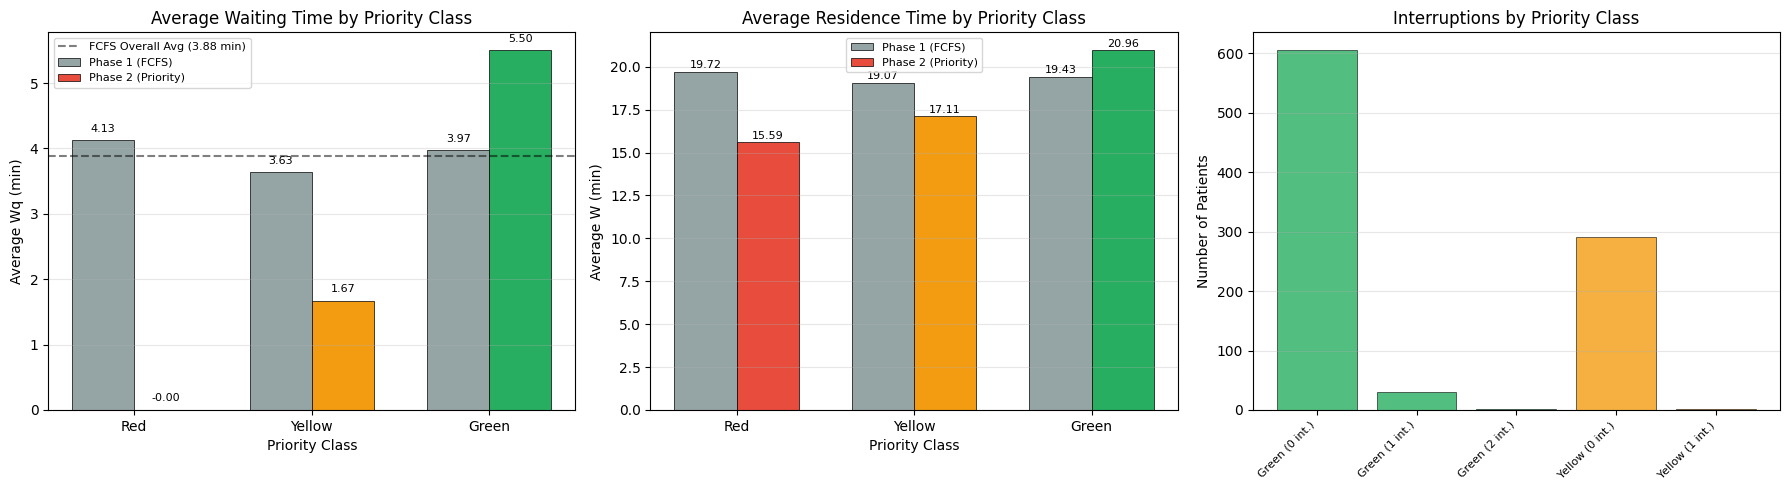

Figure saved as phase2_metrics.png


In [73]:
# ============================================================
# Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

classes = ['Red', 'Yellow', 'Green']

# ── Plot 1: Wq by Priority Class (Phase 1 vs Phase 2) ──
ax = axes[0]
phase1_wqs = [df.loc[df['Priority'] == c, 'FCFS_Wq'].mean() for c in classes]
phase2_wqs = [results.loc[results['Priority'] == c, 'Wq_Min'].mean() for c in classes]
x     = np.arange(len(classes))
width = 0.35

bars1 = ax.bar(x - width/2, phase1_wqs, width, label='Phase 1 (FCFS)',
               color='#95a5a6', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, phase2_wqs, width, label='Phase 2 (Priority)',
               color=[PRIORITY_COLORS[c] for c in classes],
               edgecolor='black', linewidth=0.5)

# Baseline line
ax.axhline(y=fcfs_wq.mean(), color='black', linestyle='--', alpha=0.5,
           label=f'FCFS Overall Avg ({fcfs_wq.mean():.2f} min)')

ax.set_xlabel('Priority Class')
ax.set_ylabel('Average Wq (min)')
ax.set_title('Average Waiting Time by Priority Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# ── Plot 2: Residence Time (W) by Priority Class ──
ax = axes[1]
phase1_ws = [df.loc[df['Priority'] == c, 'FCFS_W'].mean() for c in classes]
phase2_ws = [results.loc[results['Priority'] == c, 'W_Min'].mean() for c in classes]

bars1 = ax.bar(x - width/2, phase1_ws, width, label='Phase 1 (FCFS)',
               color='#95a5a6', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, phase2_ws, width, label='Phase 2 (Priority)',
               color=[PRIORITY_COLORS[c] for c in classes],
               edgecolor='black', linewidth=0.5)

ax.set_xlabel('Priority Class')
ax.set_ylabel('Average W (min)')
ax.set_title('Average Residence Time by Priority Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# ── Plot 3: Interruption Distribution ──
ax = axes[2]
int_data = []
int_labels = []
int_colors = []
for pclass in ['Green', 'Yellow']:
    mask   = results['Priority'] == pclass
    counts = results.loc[mask, 'Interruptions'].value_counts().sort_index()
    for k, v in counts.items():
        int_data.append(v)
        int_labels.append(f"{pclass} ({int(k)} int.)")
        int_colors.append(PRIORITY_COLORS[pclass])

ax.bar(range(len(int_data)), int_data, color=int_colors,
       edgecolor='black', linewidth=0.5, alpha=0.8)
ax.set_xticks(range(len(int_data)))
ax.set_xticklabels(int_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of Patients')
ax.set_title('Interruptions by Priority Class')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('phase2_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as phase2_metrics.png")

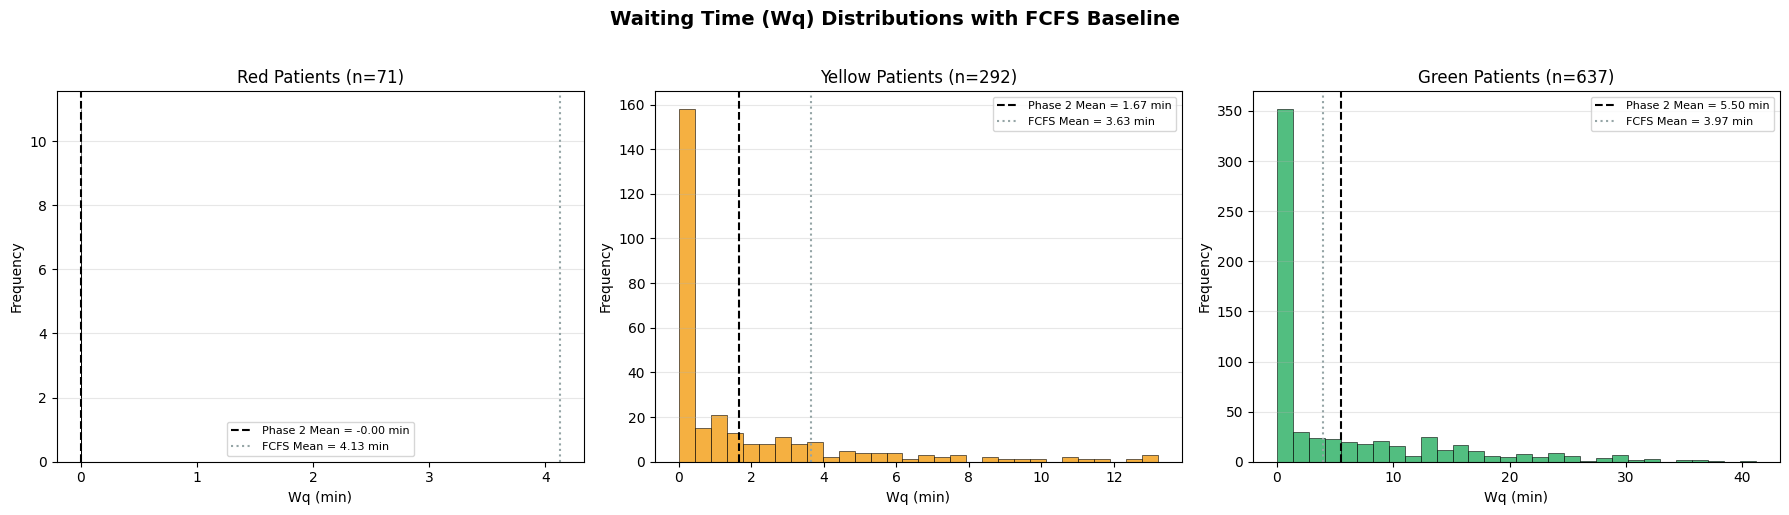

Figure saved as phase2_wq_distributions.png


In [59]:
# ============================================================
# Waiting Time Distributions by Priority Class
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, pclass in enumerate(['Red', 'Yellow', 'Green']):
    ax   = axes[idx]
    mask = results['Priority'] == pclass
    data = results.loc[mask, 'Wq_Min']

    ax.hist(data, bins=30, color=PRIORITY_COLORS[pclass],
            edgecolor='black', linewidth=0.5, alpha=0.8)

    # Mean line (Phase 2)
    mean_val = data.mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
               label=f'Phase 2 Mean = {mean_val:.2f} min')

    # FCFS mean for comparison
    fcfs_mean = df.loc[df['Priority'] == pclass, 'FCFS_Wq'].mean()
    ax.axvline(fcfs_mean, color='#95a5a6', linestyle=':', linewidth=1.5,
               label=f'FCFS Mean = {fcfs_mean:.2f} min')

    ax.set_xlabel('Wq (min)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{pclass} Patients (n={mask.sum()})')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Waiting Time (Wq) Distributions with FCFS Baseline',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('phase2_wq_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as phase2_wq_distributions.png")

In [60]:
# ============================================================
# Full Preemption Log (first 20 events)
# ============================================================

if len(preemption_log) > 0:
    pl_df = pd.DataFrame(preemption_log)
    display_cols = ['time_clock', 'red_patient', 'victim_patient',
                    'victim_priority', 'remaining_work', 'doctor',
                    'victim_interruption_count']
    pl_display = pl_df[display_cols].copy()
    pl_display.columns = ['Time', 'Red Patient', 'Victim Patient',
                          'Victim Class', 'Remaining Work (min)', 'Doctor',
                          'Victim Int. #']

    print(f"Full Preemption Log ({len(pl_df)} events total, showing first 20):")
    print("=" * 90)
    pl_display.head(20)
else:
    print("No preemptions occurred.")

Full Preemption Log (34 events total, showing first 20):


# 6. Discussion & Conclusions

## Key Findings

### 1. Impact of Priority System on Patient Classes

The introduction of the triage-based Preemptive-Resume priority system creates a clear differentiation in waiting times across patient classes:

- **Red patients** benefit significantly from near-immediate treatment. Their average $W_q$ approaches zero because they either find an idle doctor or preempt a lower-priority patient.
- **Yellow patients** experience moderate waiting. They do not preempt others but are served ahead of Green patients when doctors become free.
- **Green patients** bear the largest cost of the priority system. Their $W_q$ increases compared to FCFS because they can be preempted by Red patients and must further wait behind Yellow patients in the queue.

### 2. The Cost of Randomness

Each preemption represents a disruption to a patient's treatment continuity. However, under the **Preemptive-Resume** policy:
- No work is lost — the preempted patient's remaining treatment is preserved
- The total service capacity of the system is fully conserved
- The cost is borne entirely as **additional waiting time** for lower-priority patients

### 3. FCFS vs Priority: The Equity-Urgency Tradeoff

| Aspect | FCFS (Phase 1) | Priority (Phase 2) |
|--------|---------------|-------------------|
| Fairness | Equal Wq for all patients | Differentiated by severity |
| Clinical value | No urgency consideration | Critical patients seen first |
| Green Wq | Lower | Higher |
| Red Wq | Same as everyone | Near zero |
| Work conservation | Yes | Yes (preemptive-resume) |

### 4. Connection to Phase 1

Phase 1 established that the ER operates at $\rho = 0.7582$ with stable M/G/5 dynamics and a service $C_v = 0.39$. At this utilization level, the priority system introduces meaningful differentiation between patient classes while keeping the overall system stable. The moderate utilization means preemptions do not cascade excessively — a higher $\rho$ would amplify the cost borne by Green patients.